# Dataset description
## Sexual crimes, segregated by sex

**Source**: Ministerio de Defensa Nacional

**Download**: [link](https://www.datos.gov.co/Seguridad-y-Defensa/DELITOS-SEXUALES/bz43-8ahq/about_data)

# Code
## Imports

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Load data

In [24]:
path = "./data/DELITOS_SEXUALES_20260912.csv"

cols = [
    "FECHA HECHO",
    "SEXO",
    "CANTIDAD"
]

df = pd.read_csv(path, encoding="utf-8", usecols=cols)

## Clean data

In [25]:
df["FECHA HECHO"] = pd.to_datetime(df["FECHA HECHO"], dayfirst=True)
df["FECHA HECHO"] = df["FECHA HECHO"].dt.year

by_year = df.groupby(["FECHA HECHO", "SEXO"]).sum().reset_index()

female = by_year[by_year["SEXO"].eq("FEMENINO")]

male = by_year[by_year["SEXO"].eq("MASCULINO")]

## Plot

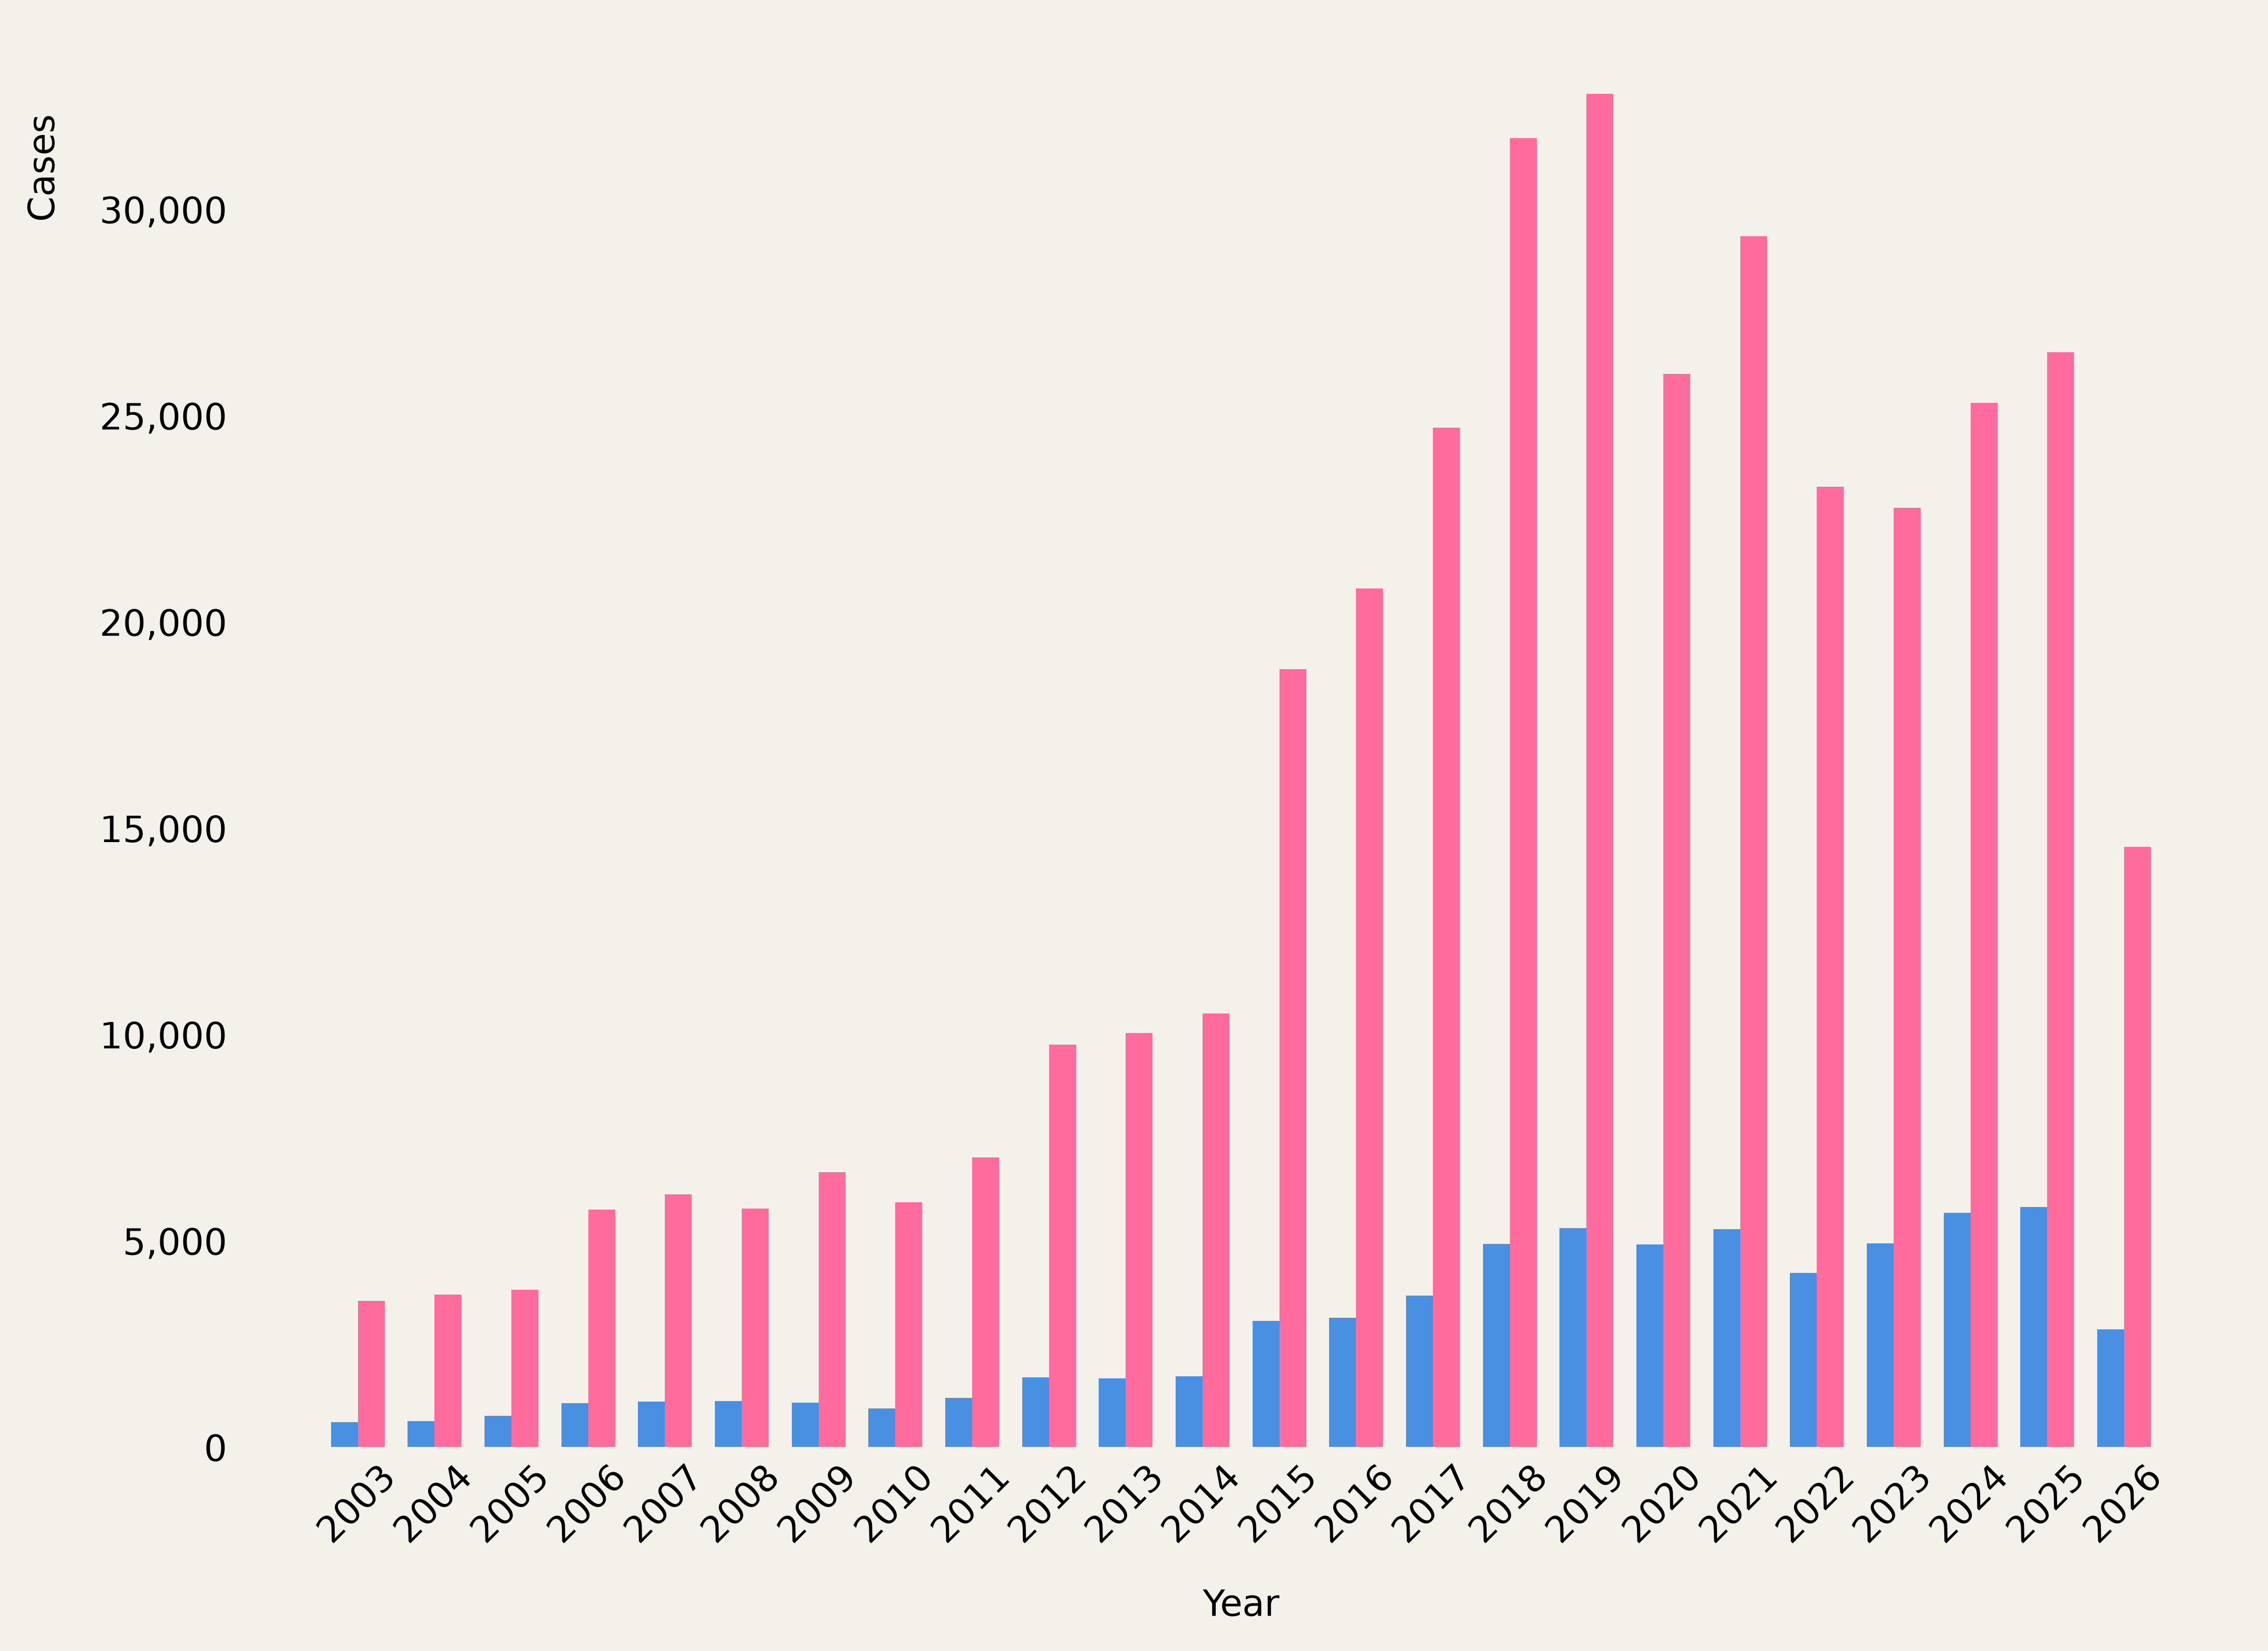

In [30]:
background = "#F4F1EA"
male_color = "#4a90e2"
female_color = "#FF6B9D"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

width = 0.35
x = range(len(male))
plt.bar([i - width/2 for i in x], male["CANTIDAD"], width, color=male_color)
plt.bar([i + width/2 for i in x], female["CANTIDAD"], width, color=female_color)

plt.xticks(ticks=x, labels=male["FECHA HECHO"], rotation=45)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Cases", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()